# 02 — Model Analysis: Results, Ablations, Error Analysis

Loads logged experiments from `results/experiments/`, compares Approach A
(classifier) vs. Approach B (autoencoder), generates ROC/PR curves,
confusion matrices, anomaly score distributions, and walks through
misclassified examples for error analysis.

**Prerequisite:** at least one run each of `src.training.train_classifier`
and `src.training.train_autoencoder` (see `scripts/train.sh`).

In [9]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from src.training.train_classifier import build_dataloaders as build_classifier_dataloaders, evaluate
from src.training.train_autoencoder import build_dataloaders as build_ae_dataloaders, compute_scores
from src.evaluation.experiment_log import load_all_experiments
from src.evaluation.metrics import roc_curve_points, pr_curve_points
from src.utils import get_device
from src.data.dataset import build_transforms
from src.visualization.gradcam import generate_gradcam_overlay

records=load_all_experiments('../results/experiments')
print(f'Loaded {len(records)} experiment records')
for r in records:
    print(f"- {r['experiment_name']} @ {r['timestamp_utc']}")

Loaded 2 experiment records
- classifier_resnet18_bottle_v1 @ 20260913T212729Z
- conv_autoencoder_bottle_v1 @ 20260913T214727Z


## 1. Summary table: all runs, key metrics side by side

In [2]:
rows=[]
for r in records:
    test=r['metrics'].get('test', {})
    rows.append({
        'run': r['experiment_name'],
        'timestamp': r['timestamp_utc'],
        'test_precision': test.get('precision'),
        'test_recall': test.get('recall'),
        'test_f1': test.get('f1'),
        'test_roc_auc': test.get('roc_auc'),
        'test_pr_auc': test.get('pr_auc'),
        'training_time_sec': r['metrics'].get('training_time_sec'),
    })
df=pd.DataFrame(rows)
df

,run,timestamp,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,training_time_sec
0,classifier_resnet18_bottle_v1,20260913T212729Z,0.906977,0.928571,0.917647,0.952381,0.985742,183.886276
1,conv_autoencoder_bottle_v1,20260913T214727Z,0.909091,0.952381,0.930233,0.908425,0.971197,1131.172683


## 2. ROC / PR curves — most recent classifier vs. autoencoder run

Requires re-running inference over the test set to get raw scores (not just
the summary metrics saved in the JSON log), since ROC/PR curves need the
full score distribution, not a single operating point.

Classifier test samples: 55
Autoencoder test samples: 55


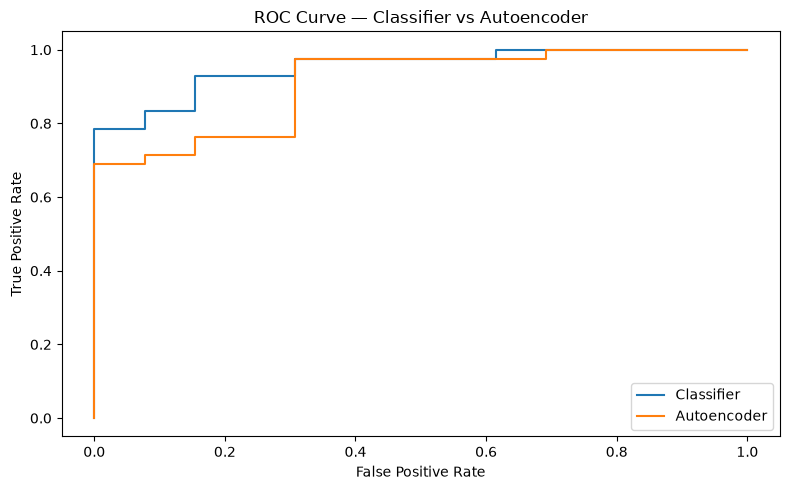

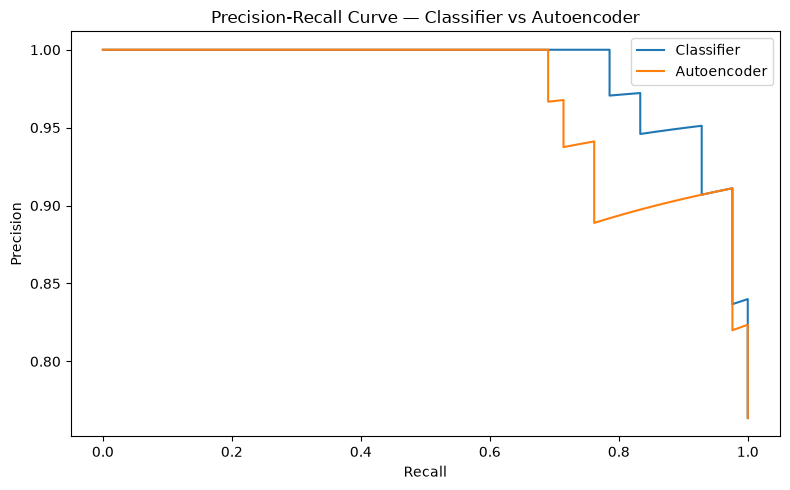

In [4]:
# recompute test-set scores for the most recent classifier and autoencoder
from src.models.classifier import DefectClassifier
from src.models.autoencoder import ConvAutoencoder, reconstruction_error_per_image

device=get_device(True)
#load checkpoints
classifier_checkpoint=torch.load(
    "../models/classifier/best_model.pt",
    map_location=device,
    weights_only=False,
)
autoencoder_checkpoint=torch.load(
    "../models/autoencoder/best_model.pt",
    map_location=device,
    weights_only=False,
)

#classifier
classifier_cfg=classifier_checkpoint["config"]
classifier_cfg["data"]["root"]="../data/mvtec_ad"
classifier_model_cfg=classifier_cfg["model"]

classifier=DefectClassifier(
    architecture=classifier_model_cfg["architecture"],
    pretrained=False,
    num_classes=classifier_model_cfg["num_classes"],
    dropout=classifier_model_cfg["dropout"],
    finetune_mode=classifier_model_cfg["finetune_mode"],
    unfrozen_layers=classifier_model_cfg.get("unfrozen_layers", []),
).to(device)
classifier.load_state_dict(classifier_checkpoint["model_state_dict"])
classifier.eval()
_, _, classifier_test_loader = build_classifier_dataloaders(classifier_cfg)
classifier_labels=[]
classifier_scores=[]
with torch.no_grad():
    for images, labels, _ in classifier_test_loader:
        logits=classifier(images.to(device))
        scores=torch.softmax(logits, dim=1)[:, 1]
        classifier_labels.extend(labels.tolist())
        classifier_scores.extend(scores.cpu().tolist())

#autoencoder
ae_cfg=autoencoder_checkpoint["config"]
ae_cfg["data"]["root"]="../data/mvtec_ad"
ae_model_cfg=ae_cfg["model"]
autoencoder=ConvAutoencoder(
    image_size=ae_cfg["data"]["image_size"],
    latent_dim=ae_model_cfg["latent_dim"],
    base_channels=ae_model_cfg["base_channels"],
    num_downsample_blocks=ae_model_cfg["num_downsample_blocks"],
).to(device)
autoencoder.load_state_dict(autoencoder_checkpoint["model_state_dict"])
autoencoder.eval()
_, _, _, ae_test_loader=build_ae_dataloaders(ae_cfg)
ae_labels, ae_scores=compute_scores(
    autoencoder,
    ae_test_loader,
    device,
)

#convert classifier results to numpy arrays
classifier_labels=np.array(classifier_labels)
classifier_scores=np.array(classifier_scores)
print(f"Classifier test samples: {len(classifier_labels)}")
print(f"Autoencoder test samples: {len(ae_labels)}")

#ROC curves
fpr_classifier, tpr_classifier, _ = roc_curve_points(
    classifier_labels,
    classifier_scores,
)
fpr_ae, tpr_ae, _ = roc_curve_points(
    ae_labels,
    ae_scores,
)
plt.figure(figsize=(8, 5))
plt.plot(
    fpr_classifier,
    tpr_classifier,
    label="Classifier",
)
plt.plot(
    fpr_ae,
    tpr_ae,
    label="Autoencoder",
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Classifier vs Autoencoder")
plt.legend()
plt.tight_layout()
plt.savefig(
    "../results/plots/roc_comparison.png",
    dpi=120,
)
plt.show()

# Precision-Recall curves
precision_classifier, recall_classifier, _ = pr_curve_points(
    classifier_labels,
    classifier_scores,
)
precision_ae, recall_ae, _ = pr_curve_points(
    ae_labels,
    ae_scores,
)
plt.figure(figsize=(8, 5))
plt.plot(
    recall_classifier,
    precision_classifier,
    label="Classifier",
)
plt.plot(
    recall_ae,
    precision_ae,
    label="Autoencoder",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Classifier vs Autoencoder")
plt.legend()
plt.tight_layout()
plt.savefig(
    "../results/plots/pr_comparison.png",
    dpi=120,
)
plt.show()

## 3. Ablation comparison

Once multiple experiment JSONs exist (e.g. `classifier_resnet18_frozen`,
`classifier_resnet18_partial`, `classifier_resnet18_full` from re-running
`configs/classifier.yaml` with different `model.finetune_mode` values), plot
them side by side here.

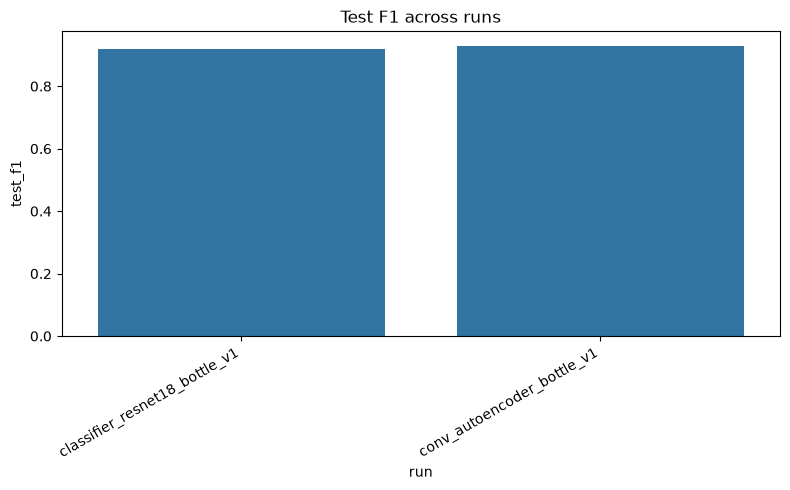

In [5]:
if len(df) > 1:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=df, x='run', y='test_f1', ax=ax)
    ax.set_title('Test F1 across runs')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('../results/plots/ablation_comparison.png', dpi=120)
    plt.show()
else:
    print('Need 2+ logged runs to compare — run more experiments first.')

## 4. Error analysis

For each model, identify: false positives (normal flagged defective),
false negatives (defective flagged normal), and the lowest-confidence
correct predictions. Visualize each with its heatmap/Grad-CAM to reason
about *why* the model likely failed (see README "Error Analysis").

False positives: 4
False negatives: 3
Lowest-confidence correct predictions: 5

False positives:
001.png score=0.575
006.png score=0.892
015.png score=0.785
018.png score=0.554

False negatives:
003.png score=0.387
004.png score=0.471
019.png score=0.470

Lowest-confidence correct:
005.png true=0 score=0.457 confidence=0.543
004.png true=0 score=0.446 confidence=0.554
010.png true=0 score=0.416 confidence=0.584
003.png true=0 score=0.407 confidence=0.593
007.png true=0 score=0.334 confidence=0.666


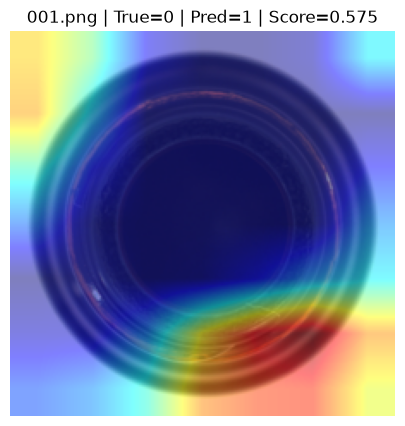

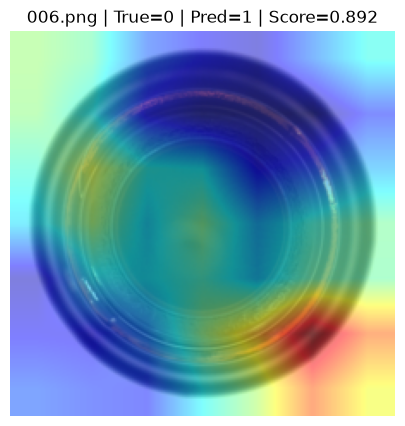

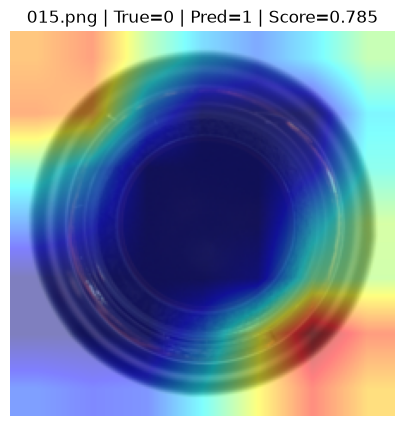

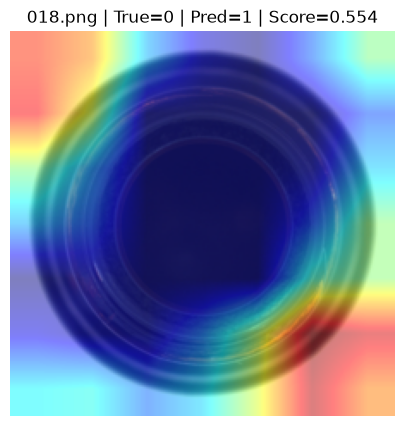

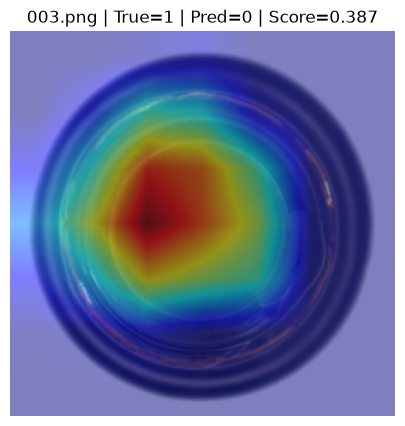

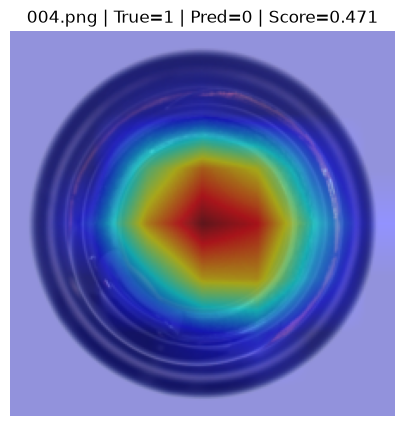

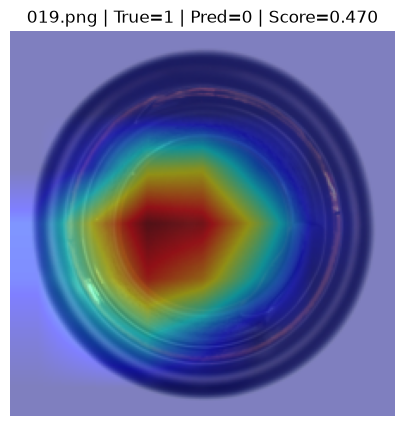

In [11]:
#error analysis: false positives, false negatives, and uncertain correct predictions
classifier_errors=[]
sample_index=0
with torch.no_grad():
    for images, labels, _ in classifier_test_loader:
        logits=classifier(images.to(device))
        probs=torch.softmax(logits, dim=1)[:, 1]

        batch_size=len(labels)

        for i, (label, score) in enumerate(
            zip(labels.tolist(), probs.cpu().tolist())
        ):
            path=classifier_test_loader.dataset.samples[
                sample_index+i
            ].image_path
            prediction=int(score>=0.5)
            confidence=score if prediction==1 else 1-score
            classifier_errors.append({
                "path": path,
                "true": label,
                "pred": prediction,
                "score": score,
                "confidence": confidence,
            })
        sample_index+=batch_size

#false positives
false_positives=[
    x for x in classifier_errors
    if x["true"]==0 and x["pred"]==1
]

#false negatives
false_negatives=[
    x for x in classifier_errors
    if x["true"]==1 and x["pred"]==0
]

#lowest-confidence correct predictions
correct_predictions=[
    x for x in classifier_errors
    if x["true"]==x["pred"]
]
uncertain_correct=sorted(
    correct_predictions,
    key=lambda x: x["confidence"]
)[:5]

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")
print(f"Lowest-confidence correct predictions: {len(uncertain_correct)}")

print("\nFalse positives:")
for x in false_positives:
    print(x["path"].name, f"score={x['score']:.3f}")

print("\nFalse negatives:")
for x in false_negatives:
    print(x["path"].name, f"score={x['score']:.3f}")

print("\nLowest-confidence correct:")
for x in uncertain_correct:
    print(
        x["path"].name,
        f"true={x['true']}",
        f"score={x['score']:.3f}",
        f"confidence={x['confidence']:.3f}"
    )

#visualize classifier errors with Grad-CAM

selected=false_positives + false_negatives
transform=build_transforms(
    image_size=classifier_cfg["data"]["image_size"],
    train=False,
    normalize=True,
)
raw_transform=build_transforms(
    image_size=classifier_cfg["data"]["image_size"],
    train=False,
    normalize=False,
)
for x in selected:
    image=Image.open(x["path"]).convert("RGB")
    image_tensor=transform(image).unsqueeze(0)
    image_rgb01=raw_transform(image).permute(1, 2, 0).numpy()
    overlay=generate_gradcam_overlay(
        classifier,
        image_tensor,
        image_rgb01,
        target_class=x["pred"],
        device=device,
    )
    plt.figure(figsize=(5, 5))
    plt.imshow(overlay)
    plt.title(
        f"{Path(x['path']).name} | "
        f"True={x['true']} | Pred={x['pred']} | "
        f"Score={x['score']:.3f}"
    )
    plt.axis("off")
    plt.show()